# 1. Análise de Trimagem Longitudinal (Curvas de Equilíbrio)
**Objetivo:** Gerar as curvas de trimagem estática para todo o envelope de voo da aeronave Vesper, desde a velocidade de estol até a velocidade máxima.

**Limites Operacionais (Baseados no Manual):**
* **V_stall:** 78 km/h (21.67 m/s)
* **V_ne:** 230 km/h (63.89 m/s)

**Metodologia:**
Utilizou-se um script em Python para automatizar a execução do AVL. Para cada ponto de velocidade discretizado no envelope:
1.  Define-se a velocidade.
2.  Aplica-se a restrição de voo nivelado (`C1` -> `Level Flight`).
3.  Aplica-se a restrição de momento de arfagem nulo (`d2 pm 0`), ajustando o profundor.
4.  Extrai-se o Ângulo de Ataque ($\alpha$), Deflexão do Profundor ($\delta_e$) e Coeficiente de Sustentação ($C_L$).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import subprocess
import os
import numpy as np
import re

In [3]:
# =============================================================================
# 1. CONFIGURAÇÃO
# =============================================================================
# Arquivos
avl_binary = r'C:\Users\andre\OneDrive\Área de Trabalho\TP MEC VOO\AVL\avl.exe' 
geometry_file = '../AVL/vesper.avl'
mass_file = '../AVL/vesper_740kg.mass' # Usando condição crítica (Pesada)

# Envelope de Voo (Convertendo km/h para m/s)
v_stall_kmh = 78
v_ne_kmh = 230

v_start = v_stall_kmh / 3.6
v_end = v_ne_kmh / 3.6

velocities = np.linspace(v_start, v_end, 50)

# Listas para guardar resultados
results = {
    'V': [],
    'Alpha': [],
    'Elevator': [],
    'CL': []
}

# =============================================================================
# 2. FUNÇÃO DE EXECUÇÃO DO AVL (CORRIGIDA)
# =============================================================================
def get_trim_point(velocity):
    """
    Roda o AVL para uma velocidade específica e retorna Alpha, Elevator e CL.
    """
    # [Resto da função get_trim_point é o mesmo...]
    # ...
    
    cmd_str = f"""
    load {geometry_file}
    mass {mass_file}
    mset 0
    oper
    c1
    v {velocity}
    
    d1 rm 0
    d2 pm 0
    d3 ym 0
    x
    
    quit
    """
    
    # Executar AVL
    # [Resto do subprocess.run é o mesmo...]
    # ...
    process = subprocess.run(
        [avl_binary],
        input=cmd_str,
        text=True,
        capture_output=True,
        check=False
    )
    
    stdout = process.stdout
    
    # --- PARSEAR O OUTPUT (COM REGEX CORRIGIDO) ---
    alpha = None
    elevator = None
    cl = None
    
    # Padrão para CLtot: Procura por 'CLtot =' seguido por um número.
    # Usamos findall e pegamos o ÚLTIMO valor (o resultado final do trim)
    cl_matches = re.findall(r"CLtot\s+=\s+(-?\d+\.\d+)", stdout)
    if cl_matches:
        cl = float(cl_matches[-1])

    # Padrão para Alpha: Procura por 'Alpha =' seguido por um número.
    # Usamos findall e pegamos o ÚLTIMO valor
    alpha_matches = re.findall(r"Alpha\s+=\s+(-?\d+\.\d+)", stdout)
    if alpha_matches:
        alpha = float(alpha_matches[-1])

    # Padrão para Profundor (Elevator) - CORRIGIDO: 
    # Procura por 'elevator =' seguido por um número.
    # Usamos findall e pegamos o ÚLTIMO valor (que está no bloco de resultados)
    elevator_matches = re.findall(r"elevator\s+=\s+(-?\d+\.\d+)", stdout)
    if elevator_matches:
        elevator = float(elevator_matches[-1])
    
    # Se ainda houver problemas com o elevator, tente este padrão mais restritivo:
    # re.search(r"elevator\s+=\s+(-?\d+\.\d+)\s", stdout[stdout.rfind("aileron"):]).group(1)
    
    return alpha, elevator, cl

# =============================================================================
# 3. LOOP DE SIMULAÇÃO
# =============================================================================
print(f"Iniciando varredura de {v_start:.2f} m/s até {v_end:.2f} m/s...")

for v in velocities:
    alpha, elev, cl = get_trim_point(v)
    
    # Se Alpha for maior que 15 graus (estol aerodinâmico) ou CL for None,
    # pode indicar que o AVL não convergiu ou entrou em regime não linear.
    if alpha is None or alpha > 16.0:
        print(f"Aviso: Não houve convergência ou Alpha > 16° para V={v:.2f} m/s. (Estol?)")
        # Paramos a varredura se Alpha for muito alto (próximo ao limite aerodinâmico do VL)
        if alpha is not None and alpha > 16.0:
             break
    
    if alpha is not None and elev is not None:
        results['V'].append(v)
        results['Alpha'].append(alpha)
        results['Elevator'].append(elev)
        results['CL'].append(cl)
        print(f"V={v:.2f} m/s | Alpha={alpha:.2f}° | Elev={elev:.2f}° | CL={cl:.3f}")

print("Cálculo concluído.")

Iniciando varredura de 21.67 m/s até 63.89 m/s...
V=21.67 m/s | Alpha=14.25° | Elev=-17.60° | CL=1.985
V=22.53 m/s | Alpha=12.55° | Elev=-14.95° | CL=1.836
V=23.39 m/s | Alpha=11.06° | Elev=-12.70° | CL=1.703
V=24.25 m/s | Alpha=9.75° | Elev=-10.76° | CL=1.584
V=25.11 m/s | Alpha=8.57° | Elev=-9.07° | CL=1.477
V=25.98 m/s | Alpha=7.53° | Elev=-7.59° | CL=1.381
V=26.84 m/s | Alpha=6.59° | Elev=-6.28° | CL=1.294
V=27.70 m/s | Alpha=5.74° | Elev=-5.12° | CL=1.214
V=28.56 m/s | Alpha=4.97° | Elev=-4.08° | CL=1.142
V=29.42 m/s | Alpha=4.27° | Elev=-3.14° | CL=1.076
V=30.28 m/s | Alpha=3.63° | Elev=-2.29° | CL=1.016
V=31.15 m/s | Alpha=3.05° | Elev=-1.53° | CL=0.960
V=32.01 m/s | Alpha=2.51° | Elev=-0.83° | CL=0.909
V=32.87 m/s | Alpha=2.02° | Elev=-0.19° | CL=0.862
V=33.73 m/s | Alpha=1.56° | Elev=0.39° | CL=0.819
V=34.59 m/s | Alpha=1.14° | Elev=0.93° | CL=0.779
V=35.45 m/s | Alpha=0.75° | Elev=1.42° | CL=0.741
V=36.32 m/s | Alpha=0.39° | Elev=1.88° | CL=0.706
V=37.18 m/s | Alpha=0.05° | E

Gráfico salvo como: envelope_trimagem_completo.png


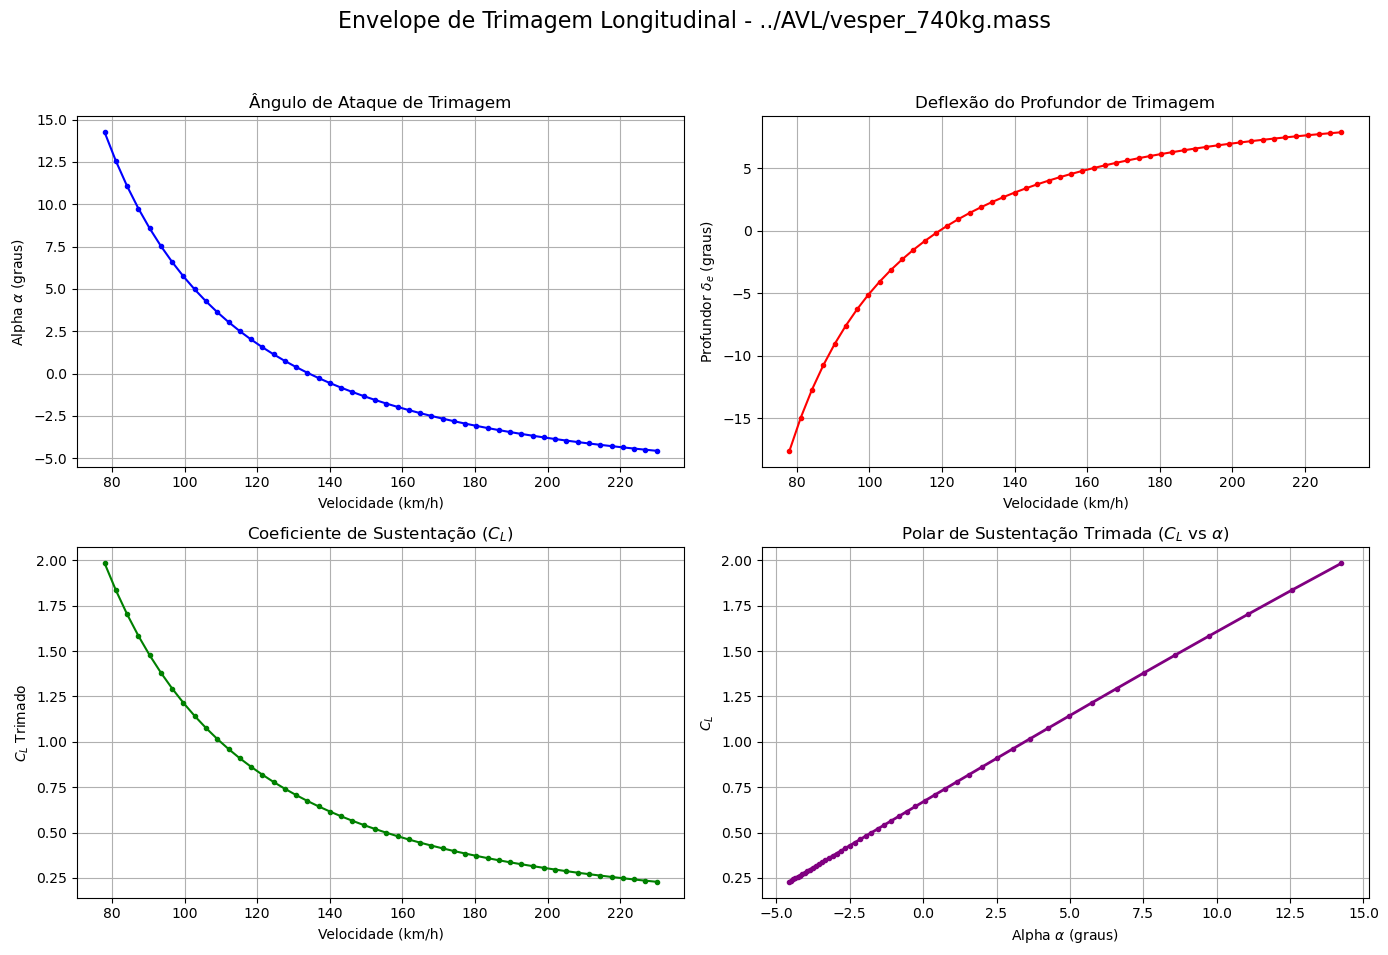

In [7]:
# Converter listas para arrays numpy para facilitar manipulação
V_arr = np.array(results['V'])
Alpha_arr = np.array(results['Alpha'])
Elev_arr = np.array(results['Elevator'])
CL_arr = np.array(results['CL'])

# Converter V para km/h
V_kmh = V_arr * 3.6

# =============================================================================
# CONFIGURAÇÃO DO PLOT (2x2)
# =============================================================================
# Cria uma figura com 2 linhas e 2 colunas
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Envelope de Trimagem Longitudinal - {mass_file}', fontsize=16)

# --- 1. Ângulo de Ataque vs Velocidade (Superior Esquerdo) ---
axs[0, 0].plot(V_kmh, Alpha_arr, color='blue', marker='o', markersize=3)
axs[0, 0].set_title('Ângulo de Ataque de Trimagem')
axs[0, 0].set_xlabel('Velocidade (km/h)')
axs[0, 0].set_ylabel(r'Alpha $\alpha$ (graus)')
axs[0, 0].grid(True)

# --- 2. Deflexão do Profundor vs Velocidade (Superior Direito) ---
axs[0, 1].plot(V_kmh, Elev_arr, color='red', marker='o', markersize=3)
axs[0, 1].set_title('Deflexão do Profundor de Trimagem')
axs[0, 1].set_xlabel('Velocidade (km/h)')
axs[0, 1].set_ylabel(r'Profundor $\delta_e$ (graus)')
axs[0, 1].grid(True)

# --- 3. Coeficiente de Sustentação vs Velocidade (Inferior Esquerdo) ---
axs[1, 0].plot(V_kmh, CL_arr, color='green', marker='o', markersize=3)
axs[1, 0].set_title('Coeficiente de Sustentação ($C_L$)')
axs[1, 0].set_xlabel('Velocidade (km/h)')
axs[1, 0].set_ylabel(r'$C_L$ Trimado')
axs[1, 0].grid(True)

# --- 4. Polar de Sustentação Trimada (CL vs Alpha) (Inferior Direito) ---
axs[1, 1].plot(Alpha_arr, CL_arr, color='purple', linewidth=2, marker='.')
axs[1, 1].set_title(r'Polar de Sustentação Trimada ($C_L$ vs $\alpha$)')
axs[1, 1].set_xlabel(r'Alpha $\alpha$ (graus)')
axs[1, 1].set_ylabel(r'$C_L$')
axs[1, 1].grid(True)

# Ajustes finais de layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Deixa espaço para o suptitle

# Salvar em alta resolução para o LaTeX
filename = 'envelope_trimagem_completo.png'
plt.savefig(filename, dpi=300, bbox_inches='tight')
print(f"Gráfico salvo como: {filename}")

plt.show()